**Author :** Rutendo F. Sigauke

# Introduction

## Summary of data

Since ENCODE candidate cis-regulatory elements (cCRE) are labeled by the type of element it is, I set out to characterize which bidirectionals overlap these features. [ENCODE cCREs Summary](https://genome.ucsc.edu/cgi-bin/hgTables?db=hg38&hgta_group=regulation&hgta_track=encodeCcreCombined&hgta_table=encodeCcreCombined&hgta_doSchema=describe+table+schema)

|Color	|UCSC label	|ENCODE classification |	ENCODE label|
|-------|-----------|----------------------|----------------|
|red	|prom       |promoter-like signature |	PLS          |
|orange	|enhP	    |proximal enhancer-like signature |	pELS  |
|yellow	|enhD	    |distal enhancer-like signature	  |dELS   |
|pink	|K4m3	    |DNase-H3K4me3	            | DNase-H3K4me3 |
|blue	|CTCF	    |CTCF-only	                |CTCF-only |


- The promoter-like signatures (PLS) fall within 200 bp of an annotated GENCODE TSS and have high DNase and H3K4me3 signals.
- The enhancer-like signatures (ELS) have high DNase and H3K27ac with low H3K4me3 max-Z score if they are within 200 bp of an annotated TSS. 

    - The subset of ELS within 2 kb of a TSS is denoted proximal (pELS), while the remaining subset is denoted distal (dELS).
    
- DNase-H3K4me3 cCREs have high H3K4me3 max-Z scores but low H3K27ac max-Z scores and do not fall within 200 bp of a TSS.

- CTCF-only cCREs have high DNase and CTCF and low H3K4me3 and H3K27ac. 
(See ENCODE website for more details)

## Methods and rational

### Fishers Exact Test

To evaluate the significance of the ENCODE candidate cis-regulatory elements (cCRE) with bidirectional regions in DBNascent, we used the Fisher Exact Test from bedtools. Given two bed files with regions, the Fisher's Exact Test is calculated based the overlapping regions from both bed files and additionally number of possible intervals are estimated based on the genome size. This is based on a the average sizes of intervals in both the ENCODE cCRE regions and DBNascent Bidirectional regions and the size of the genome.

The ENCODE cCRE categories assessed were 

- promoter-like signatures (high DNase and H3K4me3 signals), 

- distal and proximal enhancer-like signatures (high DNase and H3K27ac with low H3K4me3), 

- DNase-H3K4me3 cCREs (high H3K4me3 but low H3K27ac) and 

- CTCF-only cCREs (high DNase and CTCF and low H3K4me3 and H3K27ac).

```sh
#!/bin/bash

#SBATCH --output=/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/e_and_o/%x_%j.out
#SBATCH --error=/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/e_and_o/%x_%j.err
#SBATCH --time=00:25:00
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --mem=7MB
#SBATCH --partition short
#SBATCH --mail-type=FAIL
#SBATCH --mail-user=rutendo.sigauke@colorado.edu

module purge
module load bedtools/2.28.0

##############################
##summary of run                                                    
##############################
printf "\nRun on: $(hostname)"
printf "\nRun from: $(pwd)"
printf "\nScript: $0\n"
date

###########################
##initialize files       ## 
###########################
genomes=/scratch/Shares/dowell/genomes
wd=/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews
hg38_features=${wd}/enhancers/encodeCcreCombined_sorted.bed
mm10_features=${wd}/enhancers/mm10_encodeCcreCombined.bed
mumerge=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit
hg38_mumerge=${mumerge}/hg38_tfit_dreg_bidirectionals.bed
mm10_mumerge=${mumerge}/mm10_tfit_dreg_bidirectionals.bed
out=${wd}/processed_data/fisherstest_encode_overlaps

hg38_genome=${genomes}/hg38/ncbi/hg38.genome
mm10_genome=${genomes}/mm10/ncbi/mm10.genome

mkdir -p ${out}

##########################
##Fishers exact test    ##
##########################
#Human
for encode in `cat $hg38_features | cut -f 13 | sort | uniq`; do

    cat ${hg38_features} | grep -v "_fix\|_alt" | grep -w ${encode} | \
	bedtools fisher -a - -b ${hg38_mumerge} \
	-g ${hg38_genome} > \
	${out}/hg38_${encode}_fishers_results.txt

    cat ${hg38_features} | grep -v "_fix\|_alt" | grep -w ${encode} | \
	bedtools fisher -a - -b ${hg38_mumerge} \
	-f 0.5 -g ${hg38_genome} > \
	${out}/hg38_${encode}_fishers_results_fraction50.txt

    cat ${hg38_features} | grep -v "_fix\|_alt" | grep -w ${encode} | \
	bedtools fisher -a ${hg38_mumerge} -b - \
	-f 0.5 -g ${hg38_genome} > \
	${out}/hg38_${encode}_fishers_results_fraction50ba.txt

done

#Mouse
for encode in `cat $mm10_features | cut -f 13 | sort | uniq`; do

    cat ${mm10_features} | grep -v "_fix\|_alt" | grep -w ${encode} | \
	bedtools fisher -a - -b ${mm10_mumerge} \
	-g ${mm10_genome} > \
	${out}/mm10_${encode}_fishers_results.txt

    cat ${mm10_features} | grep -v "_fix\|_alt" | grep -w ${encode} | \
	bedtools fisher -a - -b ${mm10_mumerge} \
	-f 0.5 -g ${mm10_genome} > \
	${out}/mm10_${encode}_fishers_results_fraction50.txt

    cat ${mm10_features} | grep -v "_fix\|_alt" | grep -w ${encode} | \
	bedtools fisher -a ${mm10_mumerge} -b - \
	-f 0.5 -g ${mm10_genome} > \
	${out}/mm10_${encode}_fishers_results_fraction50ba.txt

done
 
echo "DONE!"


```

### Permutation and empirical p-values

The Fishers exact test assumes that the regions can be evenly distributed across the genome. However, there are regions in the genome without any transcription. To account for this, a permutation test only allowing shuffled regions in areas where we expect transcription was performed. Regions of transcription were defined as bidirectional regions + 5kb window on both ends, gene regions + 5kb upstream of TSS and 30kb downstream of TES. Importantly, restricting the shuffling to be done within each chromosome. Regions were shuffled 1000 times.


The empirical p-value was calculated using the following formula \cite{Davison1997bootstrap,North2002note,Jd2003statistical,Storey2005significance}:

p-value = (r+1)/(n+1)

Where _r_ is the sum of values in the random distribution (all shuffled overlaps) that are greater than the observed value (true overlap), and _n_ is the sample size of the randomized distribution.

```sh
#!/bin/bash

#SBATCH --output=/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/e_and_o/%x_%j.out
#SBATCH --error=/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/e_and_o/%x_%j.err
#SBATCH --time=24:00:00
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --mem=10GB
#SBATCH --partition short
#SBATCH --mail-type=FAIL
#SBATCH --mail-user=rutendo.sigauke@colorado.edu

module purge
module load bedtools/2.28.0

##############################
##summary of run                                                    
##############################
printf "\nRun on: $(hostname)"
printf "\nRun from: $(pwd)"
printf "\nScript: $0\n"
date

###########################
##initialize files       ## 
###########################
mumerge=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit
genomes=/scratch/Shares/dowell/genomes
wd=/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews

hg38_features=${wd}/enhancers/encodeCcreCombined_sorted.bed
mm10_features=${wd}/enhancers/mm10_encodeCcreCombined.bed

hg38_mumerge=${mumerge}/hg38_tfit_dreg_bidirectionals.bed
mm10_mumerge=${mumerge}/mm10_tfit_dreg_bidirectionals.bed

hg38_refseq=${genomes}/hg38/ncbi/hg38_refseq_diff53prime_with_putatives.bed
mm10_refseq=${genomes}/mm10/ncbi/mm10_refseq_diff53prime_with_putatives.bed 

hg38_genome=${genomes}/hg38/ncbi/hg38.genome
mm10_genome=${genomes}/mm10/ncbi/mm10.genome

out=${wd}/processed_data/permutation_encode_overlaps
mkdir -p ${out}

#################################
##Define transcribed regions   ##
#################################
#1. Pad gene regions as we know these regions tend to be transcribed (slop 500 bp upstream of TSS (-l 500) and 30kb from PAS (-r 30000))
bedtools slop -i ${hg38_refseq} -g ${hg38_genome} -l 500 -r 30000 -s > ${out}/hg38_refseq_diff53prime_SLOP.bed
bedtools slop -i ${mm10_refseq} -g ${mm10_genome} -l 500 -r 30000 -s > ${out}/mm10_refseq_diff53prime_SLOP.bed

#2. Add pad to bidirectional transcripts
bedtools slop -i ${hg38_mumerge} -g ${hg38_genome} -b 5000 > ${out}/hg38_bidirectionals_SLOP.bed
bedtools slop -i ${mm10_mumerge} -g ${mm10_genome} -b 5000 > ${out}/mm10_bidirectionals_SLOP.bed

#3. Merge regions with transcription (i.e. genes and bidirectional transcripts)
cat ${out}/hg38_refseq_diff53prime_SLOP.bed ${out}/hg38_bidirectionals_SLOP.bed | \
    bedtools sort -i - | \
    bedtools merge -i - > ${out}/hg38_transcribed_regions.bed

cat ${out}/mm10_refseq_diff53prime_SLOP.bed ${out}/mm10_bidirectionals_SLOP.bed | \
    bedtools sort -i - | \
    bedtools merge -i - > ${out}/mm10_transcribed_regions.bed

#4. Get regions not transcribed in the genome
bedtools complement -i ${out}/hg38_transcribed_regions.bed -g ${hg38_genome} > ${out}/hg38_NOT_transcribed_regions.bed
bedtools complement -i ${out}/mm10_transcribed_regions.bed -g ${mm10_genome} > ${out}/mm10_NOT_transcribed_regions.bed

##############################
#get overlaps               ##
##############################
#5. Overlap bidirectionals regions and features
bedtools intersect -a ${hg38_mumerge} -b ${hg38_features} -wo > ${out}/hg38_encode_bidir_overlapReportAll_bp.bed
bedtools intersect -a ${mm10_mumerge} -b ${mm10_features} -wo > ${out}/mm10_encode_bidir_overlapReportAll_bp.bed

#6. Perform a randomization of regions in regions transcribed and within the same chromosome
iter=1000 #iterate this number of times

for i in $(seq 1 $iter); do
    #shuffle regions, only in transcribed regions, within chromosome and not allowing overlaps
    bedtools shuffle -i ${hg38_mumerge} \
	-g ${hg38_genome} \
	-incl ${out}/hg38_transcribed_regions.bed \
	-chrom -seed ${i} -noOverlapping > \
	${out}/hg38_bidirectionals_seed${i}_shuffled.bed 
    
    bedtools shuffle -i ${mm10_mumerge} \
	-g ${mm10_genome} \
	-incl ${out}/mm10_transcribed_regions.bed \
	-chrom -seed ${i} -noOverlapping > \
	${out}/mm10_bidirectionals_seed${i}_shuffled.bed
    
    #intersect of shuffled regions with ENCODE
    bedtools intersect \
	-a ${out}/hg38_bidirectionals_seed${i}_shuffled.bed \
	-b ${hg38_features} -wo > \
	${out}/hg38_encode_bidir_seed${i}_shuffled_overlap.bed
    
    bedtools intersect \
	-a ${out}/mm10_bidirectionals_seed${i}_shuffled.bed \
	-b ${mm10_features} -wo > \
	${out}/mm10_encode_bidir_seed${i}_shuffled_overlap.bed

done 

echo "DONE!"

```

# Load libraries

In [1]:
library(data.table) # easy import of large tables
library(dplyr)      # data wrangling
library(ggplot2)    # plotting
library(cowplot)    # plotting
library(scales)     # plotting
library(qvalue)     #empirical p-value calculation


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Functions

## P-value calculation

In [2]:
empirical_pval <- function(random_dist, observed_value, alternative = c("two.sided", "less", "greater")) {

    #https://pmc.ncbi.nlm.nih.gov/articles/PMC379178/
    alternative <- match.arg(alternative)

    r <- sum(random_dist > observed_value)
    n <- length(random_dist)
    p <- (r + 1) / (n + 1) 

    if (alternative == "greater") {
    pval <- p
    } else if (alternative == "less") {
    pval <- 1 - p
    } else if (alternative == "two.sided") {
    pval <- 2 * min(p, 1 - p)
    }
    return(pval)
}

# Load data

## ENCODE regions

### Human

In [3]:
hg38_encode <- data.table::fread("/Users/rusi2317/projects/meta_analysis_qc/hg38/enhancers/ENCODE/encodeCcreCombined_sorted.bed")
colnames(hg38_encode) <- c("chrom","chromStart", "chromEnd",
                "name","score","strand",
                "thickStart","thickEnd","reserved",
                "ccre","encodeLabel", "zScore", "ucscLabel",
                "accessionLabel","description")

#add encode ID
hg38_encode$encode_id <- paste0(hg38_encode$chrom,":",
                               hg38_encode$chromStart,"-",
                               hg38_encode$chromEnd)
dim(hg38_encode)
head(hg38_encode, 3)

[1] 926535     16

chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,reserved,ccre,encodeLabel,zScore,ucscLabel,accessionLabel,description,encode_id
<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
chr1,181251,181601,EH38E1310153,488,.,181251,181601,"255,167,0","pELS,CTCF-bound",pELS,4.884033,enhP,E1310153,EH38E1310153 proximal enhancer-like signature,chr1:181251-181601
chr1,190865,191071,EH38E1310154,179,.,190865,191071,"255,205,0","dELS,CTCF-bound",dELS,1.792822,enhD,E1310154,EH38E1310154 distal enhancer-like signature,chr1:190865-191071
chr1,778562,778912,EH38E1310158,759,.,778562,778912,"255,0,0","PLS,CTCF-bound",PLS,7.598523,prom,E1310158,EH38E1310158 promoter-like signature,chr1:778562-778912


### Mouse

In [4]:
mm10_encode <- data.table::fread("/Users/rusi2317/projects/meta_analysis_qc/mm10/enhancers/ENCODE/mm10_encodeCcreCombined.bed")
colnames(mm10_encode) <- c("chrom","chromStart", "chromEnd",
                "name","score","strand",
                "thickStart","thickEnd","reserved",
                "ccre","encodeLabel", "zScore", "ucscLabel",
                "accessionLabel","description")
#add encode id
mm10_encode$encode_id <- paste0(mm10_encode$chrom,":",
                               mm10_encode$chromStart,"-",
                               mm10_encode$chromEnd)
dim(mm10_encode)
head(mm10_encode, 3)

[1] 343731     16

chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,reserved,ccre,encodeLabel,zScore,ucscLabel,accessionLabel,description,encode_id
<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
chr1,3119617,3119911,EM10E0431203,303,.,3119617,3119911,"255,205,0",dELS,dELS,3.039313,enhD,E0431203,EM10E0431203 distal enhancer-like signature,chr1:3119617-3119911
chr1,3119914,3120120,EM10E0431204,264,.,3119914,3120120,"255,205,0",dELS,dELS,2.641441,enhD,E0431204,EM10E0431204 distal enhancer-like signature,chr1:3119914-3120120
chr1,3120346,3120662,EM10E0431205,263,.,3120346,3120662,"255,205,0",dELS,dELS,2.638581,enhD,E0431205,EM10E0431205 distal enhancer-like signature,chr1:3120346-3120662


## Overlap counts

### Human

In [5]:
#load the true overlaps
wd <- '/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/permutation_encode_overlaps/'

hg38_overlap <- data.table::fread(paste0(wd, "hg38_encode_bidir_overlapReportAll_bp.bed"))

#rename columns
colnames(hg38_overlap) <- c("chr_bidir", "start_bidir",
                            "stop_bidir","bidir","score_bidir",
                            "strand_bidir","chrom","chromStart",
                            "chromEnd", "name","score","strand",
                            "thickStart","thickEnd","reserved",
                            "ccre","encodeLabel", "zScore", "ucscLabel",
                            "accessionLabel","description","overlap")

#add an encode ID columns
hg38_overlap$encode_id <- paste0(hg38_overlap$chrom,":",
                               hg38_overlap$chromStart,"-",
                               hg38_overlap$chromEnd)
dim(hg38_overlap)
head(hg38_overlap, 2)

[1] 436736     23

chr_bidir,start_bidir,stop_bidir,bidir,score_bidir,strand_bidir,chrom,chromStart,chromEnd,name,⋯,thickEnd,reserved,ccre,encodeLabel,zScore,ucscLabel,accessionLabel,description,overlap,encode_id
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,181223,181645,tfit,4,.,chr1,181251,181601,EH38E1310153,⋯,181601,"255,167,0","pELS,CTCF-bound",pELS,4.884033,enhP,E1310153,EH38E1310153 proximal enhancer-like signature,350,chr1:181251-181601
chr1,778597,778849,"tfit,dreg",181,.,chr1,778562,778912,EH38E1310158,⋯,778912,"255,0,0","PLS,CTCF-bound",PLS,7.598523,prom,E1310158,EH38E1310158 promoter-like signature,252,chr1:778562-778912


In [6]:
#load the shuffled counts
hg38_shuffle_overlap_counts <- '/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/permutation_encode_overlaps/shuffled_counts_hg38.txt'
hg38_shuffle_overlap <- data.table::fread(hg38_shuffle_overlap_counts, sep = ",")

#add column names
colnames(hg38_shuffle_overlap) <- c("file_loaded", "ucscLabel","n_overlap")
hg38_shuffle_overlap$seed <- as.character(lapply(strsplit(hg38_shuffle_overlap$file_loaded, '_'), `[`, 4)) 
dim(hg38_shuffle_overlap)
head(hg38_shuffle_overlap, 2)

[1] 5000    4

file_loaded,ucscLabel,n_overlap,seed
<chr>,<chr>,<int>,<chr>
hg38_encode_bidir_seed1000_shuffled_overlap.bed,CTCF,11501,seed1000
hg38_encode_bidir_seed1000_shuffled_overlap.bed,enhD,149877,seed1000


### Mouse

In [7]:
#load the true mouse overlaps
mm10_overlap <- data.table::fread(paste0(wd, "mm10_encode_bidir_overlapReportAll_bp.bed"))

#add column names
colnames(mm10_overlap) <- c("chr_bidir", "start_bidir",
                            "stop_bidir","bidir","score_bidir",
                            "strand_bidir","chrom","chromStart",
                            "chromEnd", "name","score","strand",
                            "thickStart","thickEnd","reserved",
                            "ccre","encodeLabel", "zScore", "ucscLabel",
                            "accessionLabel","description","overlap")

#add an encode ID columns
mm10_overlap$encode_id <- paste0(mm10_overlap$chrom,":",
                               mm10_overlap$chromStart,"-",
                               mm10_overlap$chromEnd)
dim(mm10_overlap)
head(mm10_overlap, 2)

[1] 211360     23

chr_bidir,start_bidir,stop_bidir,bidir,score_bidir,strand_bidir,chrom,chromStart,chromEnd,name,⋯,thickEnd,reserved,ccre,encodeLabel,zScore,ucscLabel,accessionLabel,description,overlap,encode_id
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,3119802,3120542,"tfit,dreg",2,.,chr1,3119617,3119911,EM10E0431203,⋯,3119911,"255,205,0",dELS,dELS,3.039313,enhD,E0431203,EM10E0431203 distal enhancer-like signature,109,chr1:3119617-3119911
chr1,3119802,3120542,"tfit,dreg",2,.,chr1,3119914,3120120,EM10E0431204,⋯,3120120,"255,205,0",dELS,dELS,2.641441,enhD,E0431204,EM10E0431204 distal enhancer-like signature,206,chr1:3119914-3120120


In [8]:
#load the shuffled counts
mm10_shuffle_overlap_counts <- '/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/permutation_encode_overlaps/shuffled_counts_mm10.txt'

#add column names
mm10_shuffle_overlap <- data.table::fread(mm10_shuffle_overlap_counts, sep = ",")
colnames(mm10_shuffle_overlap) <- c("file_loaded", "ucscLabel","n_overlap")
mm10_shuffle_overlap$seed <- as.character(lapply(strsplit(mm10_shuffle_overlap$file_loaded, '_'), `[`, 4)) 
dim(mm10_shuffle_overlap)
head(mm10_shuffle_overlap, 2)

[1] 5000    4

file_loaded,ucscLabel,n_overlap,seed
<chr>,<chr>,<int>,<chr>
mm10_encode_bidir_seed1000_shuffled_overlap.bed,CTCF,4723,seed1000
mm10_encode_bidir_seed1000_shuffled_overlap.bed,enhD,43472,seed1000


## Fisher's Exact Test results

In [9]:
fishers_folder <- "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps"


##get paths for the shuffled overlaps
fishers_files <- list.files(path=fishers_folder,
                         pattern="results_fraction50ba.txt",
                         full.names=TRUE)

fishers_files


[1] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_CTCF_fishers_results_fraction50ba.txt"
 [2] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_enhD_fishers_results_fraction50ba.txt"
 [3] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_enhP_fishers_results_fraction50ba.txt"
 [4] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_K4m3_fishers_results_fraction50ba.txt"
 [5] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_prom_fishers_results_fraction50ba.txt"
 [6] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/mm10_CTCF_fishers_results_fraction50ba.txt"
 [7] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/mm10_enhD_fishers_results_fraction50ba.txt"
 [8] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/mm10_enhP_fishers_results_fraction50ba.txt"
 [9] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/mm10_K4m3_fishers_results_fraction50ba.txt"
[10] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/mm10_prom_fishers_results_fraction50ba.txt"

In [10]:
##load all fishers results
fishers_DT_list <- lapply(fishers_files,
                               data.table::fread,
                               nThread = 10, 
                         fill=TRUE) 

# Assess overlaps 

## Fishers exact test

In [11]:
##get paths for the file names
fishers_file_names <- list.files(path=fishers_folder,
                         pattern="results_fraction50ba.txt",
                         full.names=FALSE)
fishers_genomes <- as.character(lapply(strsplit(fishers_file_names, '_'), `[`, 1)) 


In [12]:
for (i in 1:length(fishers_DT_list)){
    
    print("-------------------------------------")
    
    print(fishers_files[i])
    fishers_genome <- as.character(lapply(strsplit(fishers_file_names[i], '_'), `[`, 1)) 
    fishers_ccre <- as.character(lapply(strsplit(fishers_file_names[i], '_'), `[`, 2)) 
    
    print(paste0("Genome      = ", fishers_genome))
    print(paste0("ENCODE cCRE = ", fishers_ccre))
    
    #get the phyper expression
    hype_eqn <- parse(text=paste0(fishers_DT_list[[i]][5,2],
                                    fishers_DT_list[[i]][5,3],
                                    fishers_DT_list[[i]][5,4],
                                    fishers_DT_list[[i]][5,5],
                                    fishers_DT_list[[i]][5,6],
                                    fishers_DT_list[[i]][5,7],
                                    fishers_DT_list[[i]][5,8],
                                    fishers_DT_list[[i]][5,9],
                                    fishers_DT_list[[i]][5,10]))
    print(hype_eqn)
    #print(paste0("Equations    = ", print(hype_eqn))
          
    pval <- eval(hype_eqn)
          
    print(paste0("P-value      = ", pval))
    print("-------------------------------------")
}

[1] "-------------------------------------"
[1] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_CTCF_fishers_results_fraction50ba.txt"
[1] "Genome      = hg38"
[1] "ENCODE cCRE = CTCF"
expression(phyper(94537 - 1, 847521, 4600413 - 847521, 388814, 
    lower.tail = F))
[1] "P-value      = 0"
[1] "-------------------------------------"
[1] "-------------------------------------"
[1] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_enhD_fishers_results_fraction50ba.txt"
[1] "Genome      = hg38"
[1] "ENCODE cCRE = enhD"
expression(phyper(152401 - 1, 847521, 4499584 - 847521, 667599, 
    lower.tail = F))
[1] "P-value      = 0"
[1] "-------------------------------------"
[1] "-------------------------------------"
[1] "/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/fisherstest_encode_overlaps/hg38_enhP_fishers_results_fraction50ba.txt"
[1] "Genome  

## Permutation tests

### Human

In [13]:
hg38_ucsc_types <- unique(hg38_encode$ucscLabel)
hg38_ucsc_types_plot_list <- list()


for (i in hg38_ucsc_types){
    
    print("--------------------------------")
    print(i)
    
    #1: subset the encode feature
    hg38_shuffle_subtype_num <- subset(hg38_shuffle_overlap, ucscLabel == i)
    
    #2: count number of ALL encode features __by type__
    hg38_encode_subtype <- subset(hg38_encode, ucscLabel == i)
    n_encode_subtype <- length(unique(hg38_encode_subtype$encode_id))
    
    #3: get percent (%) of overlaps for all shuffled regions
    hg38_shuffle_subtype_num$perc_overlap <- 100*(hg38_shuffle_subtype_num$n_overlap/n_encode_subtype)
    #hg38_shuffle_subtype_perc <- 100*(hg38_shuffle_subtype_num/n_encode_subtype)
    
    #4: get overlapsfor TRUE SET __by type__ 
    hg38_overlap_subtype <- subset(hg38_overlap, ucscLabel == i)
    hg38_actual_overlap_encode_subtype <-length(unique(hg38_overlap_subtype$encode_id))
    hg38_actual_overlap_encode_subtype_perc <- 100*(hg38_actual_overlap_encode_subtype/n_encode_subtype)
    
    
    #5: get the p-value
    p_val_subtype <- empirical_pval(hg38_shuffle_subtype_num$perc_overlap,
                                    hg38_actual_overlap_encode_subtype_perc, 
                                    alternative = "two.sided")
    
    print(paste0(i, " P-value = ",p_val_subtype))
    print(paste0(i, " Number of recovered = ", hg38_actual_overlap_encode_subtype))
    
    #6: plot the distribution
    hg38_perc_overlap_subtype_plot <- ggplot(hg38_shuffle_subtype_num, aes(x=perc_overlap)) + 
        geom_histogram(color="black", fill="gray80", bins = 100) +
        geom_vline(xintercept = hg38_actual_overlap_encode_subtype_perc,
                   linetype="dashed", 
                        color = "#d7191c", linewidth=1) +
        scale_y_continuous(expand = c(0, 0)) +
        theme_cowplot(24) +
          labs(title = i, 
               y = "Count",
               x = "ENCODE cCREs overlapping bidirectional regions (%)") +
        theme(plot.title = element_text(hjust = 0.5, face="plain"),
              title = element_text(size = 28), 
              axis.title = element_text(size = 26), 
              axis.text = element_text(size = 24)) +
        theme(plot.margin = margin(0.5,1,0.5,0.5, "cm"))

     #add median counts  
     hg38_perc_overlap_subtype_plot2 <- hg38_perc_overlap_subtype_plot + annotate(geom="text", 
             x=round(0.9*max(c(hg38_shuffle_subtype_num$perc_overlap,
                               hg38_actual_overlap_encode_subtype_perc))),
             y=round(0.9*max(ggplot_build(hg38_perc_overlap_subtype_plot)$data[[1]]$count)), 
             size=10,
             label=paste0("N = ", 
                          hg38_actual_overlap_encode_subtype),
             color="#d7191c") 

    
    hg38_ucsc_types_plot_list[[i]] <- hg38_perc_overlap_subtype_plot2
    
    
}

[1] "--------------------------------"
[1] "enhP"
[1] "enhP P-value = 0.001998001998002"
[1] "enhP Number of recovered = 66720"
[1] "--------------------------------"
[1] "enhD"
[1] "enhD P-value = 0.001998001998002"
[1] "enhD Number of recovered = 312649"
[1] "--------------------------------"
[1] "prom"
[1] "prom P-value = 0.001998001998002"
[1] "prom Number of recovered = 23143"
[1] "--------------------------------"
[1] "CTCF"
[1] "CTCF P-value = 0"
[1] "CTCF Number of recovered = 10088"
[1] "--------------------------------"
[1] "K4m3"
[1] "K4m3 P-value = 0.001998001998002"
[1] "K4m3 Number of recovered = 6897"


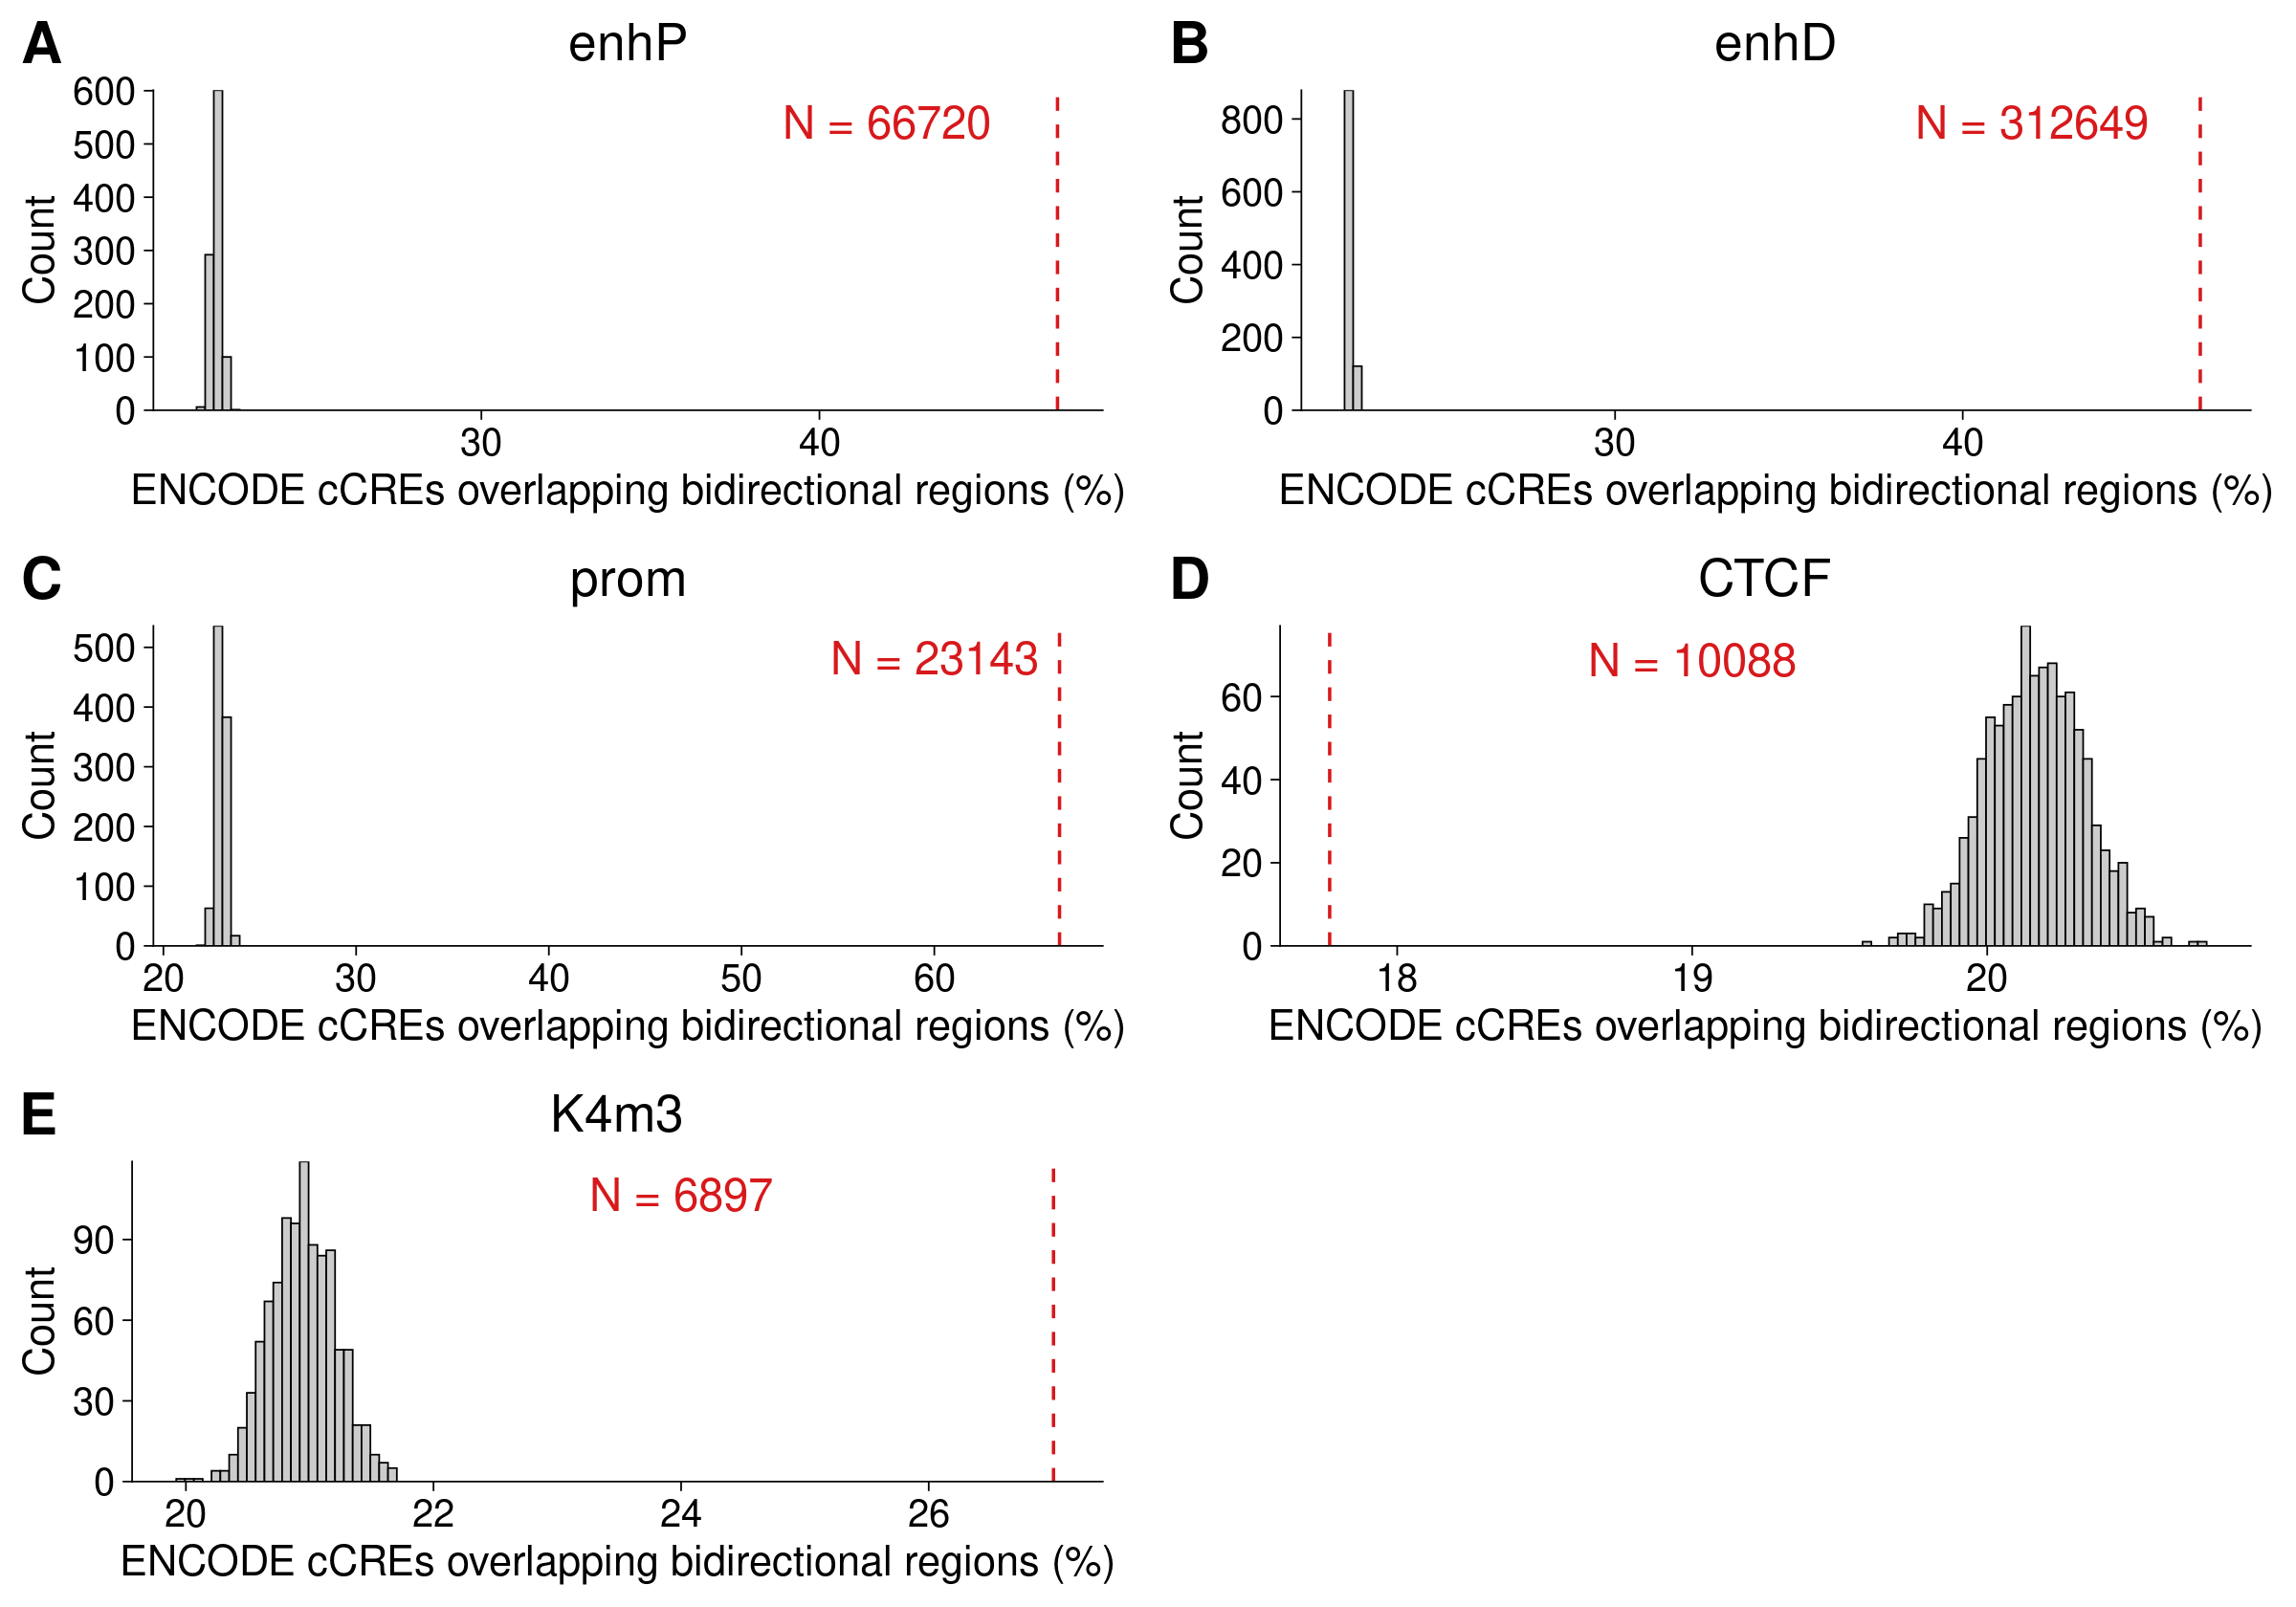

In [14]:
options(repr.plot.width=20, repr.plot.height=14)
hg38_ucsc_types_plots <- cowplot::plot_grid(plotlist = hg38_ucsc_types_plot_list, 
                                               nrow = 3,
                                      labels = c('A', 'B','C','D','E'),
                                      label_size = 36)
hg38_ucsc_types_plots

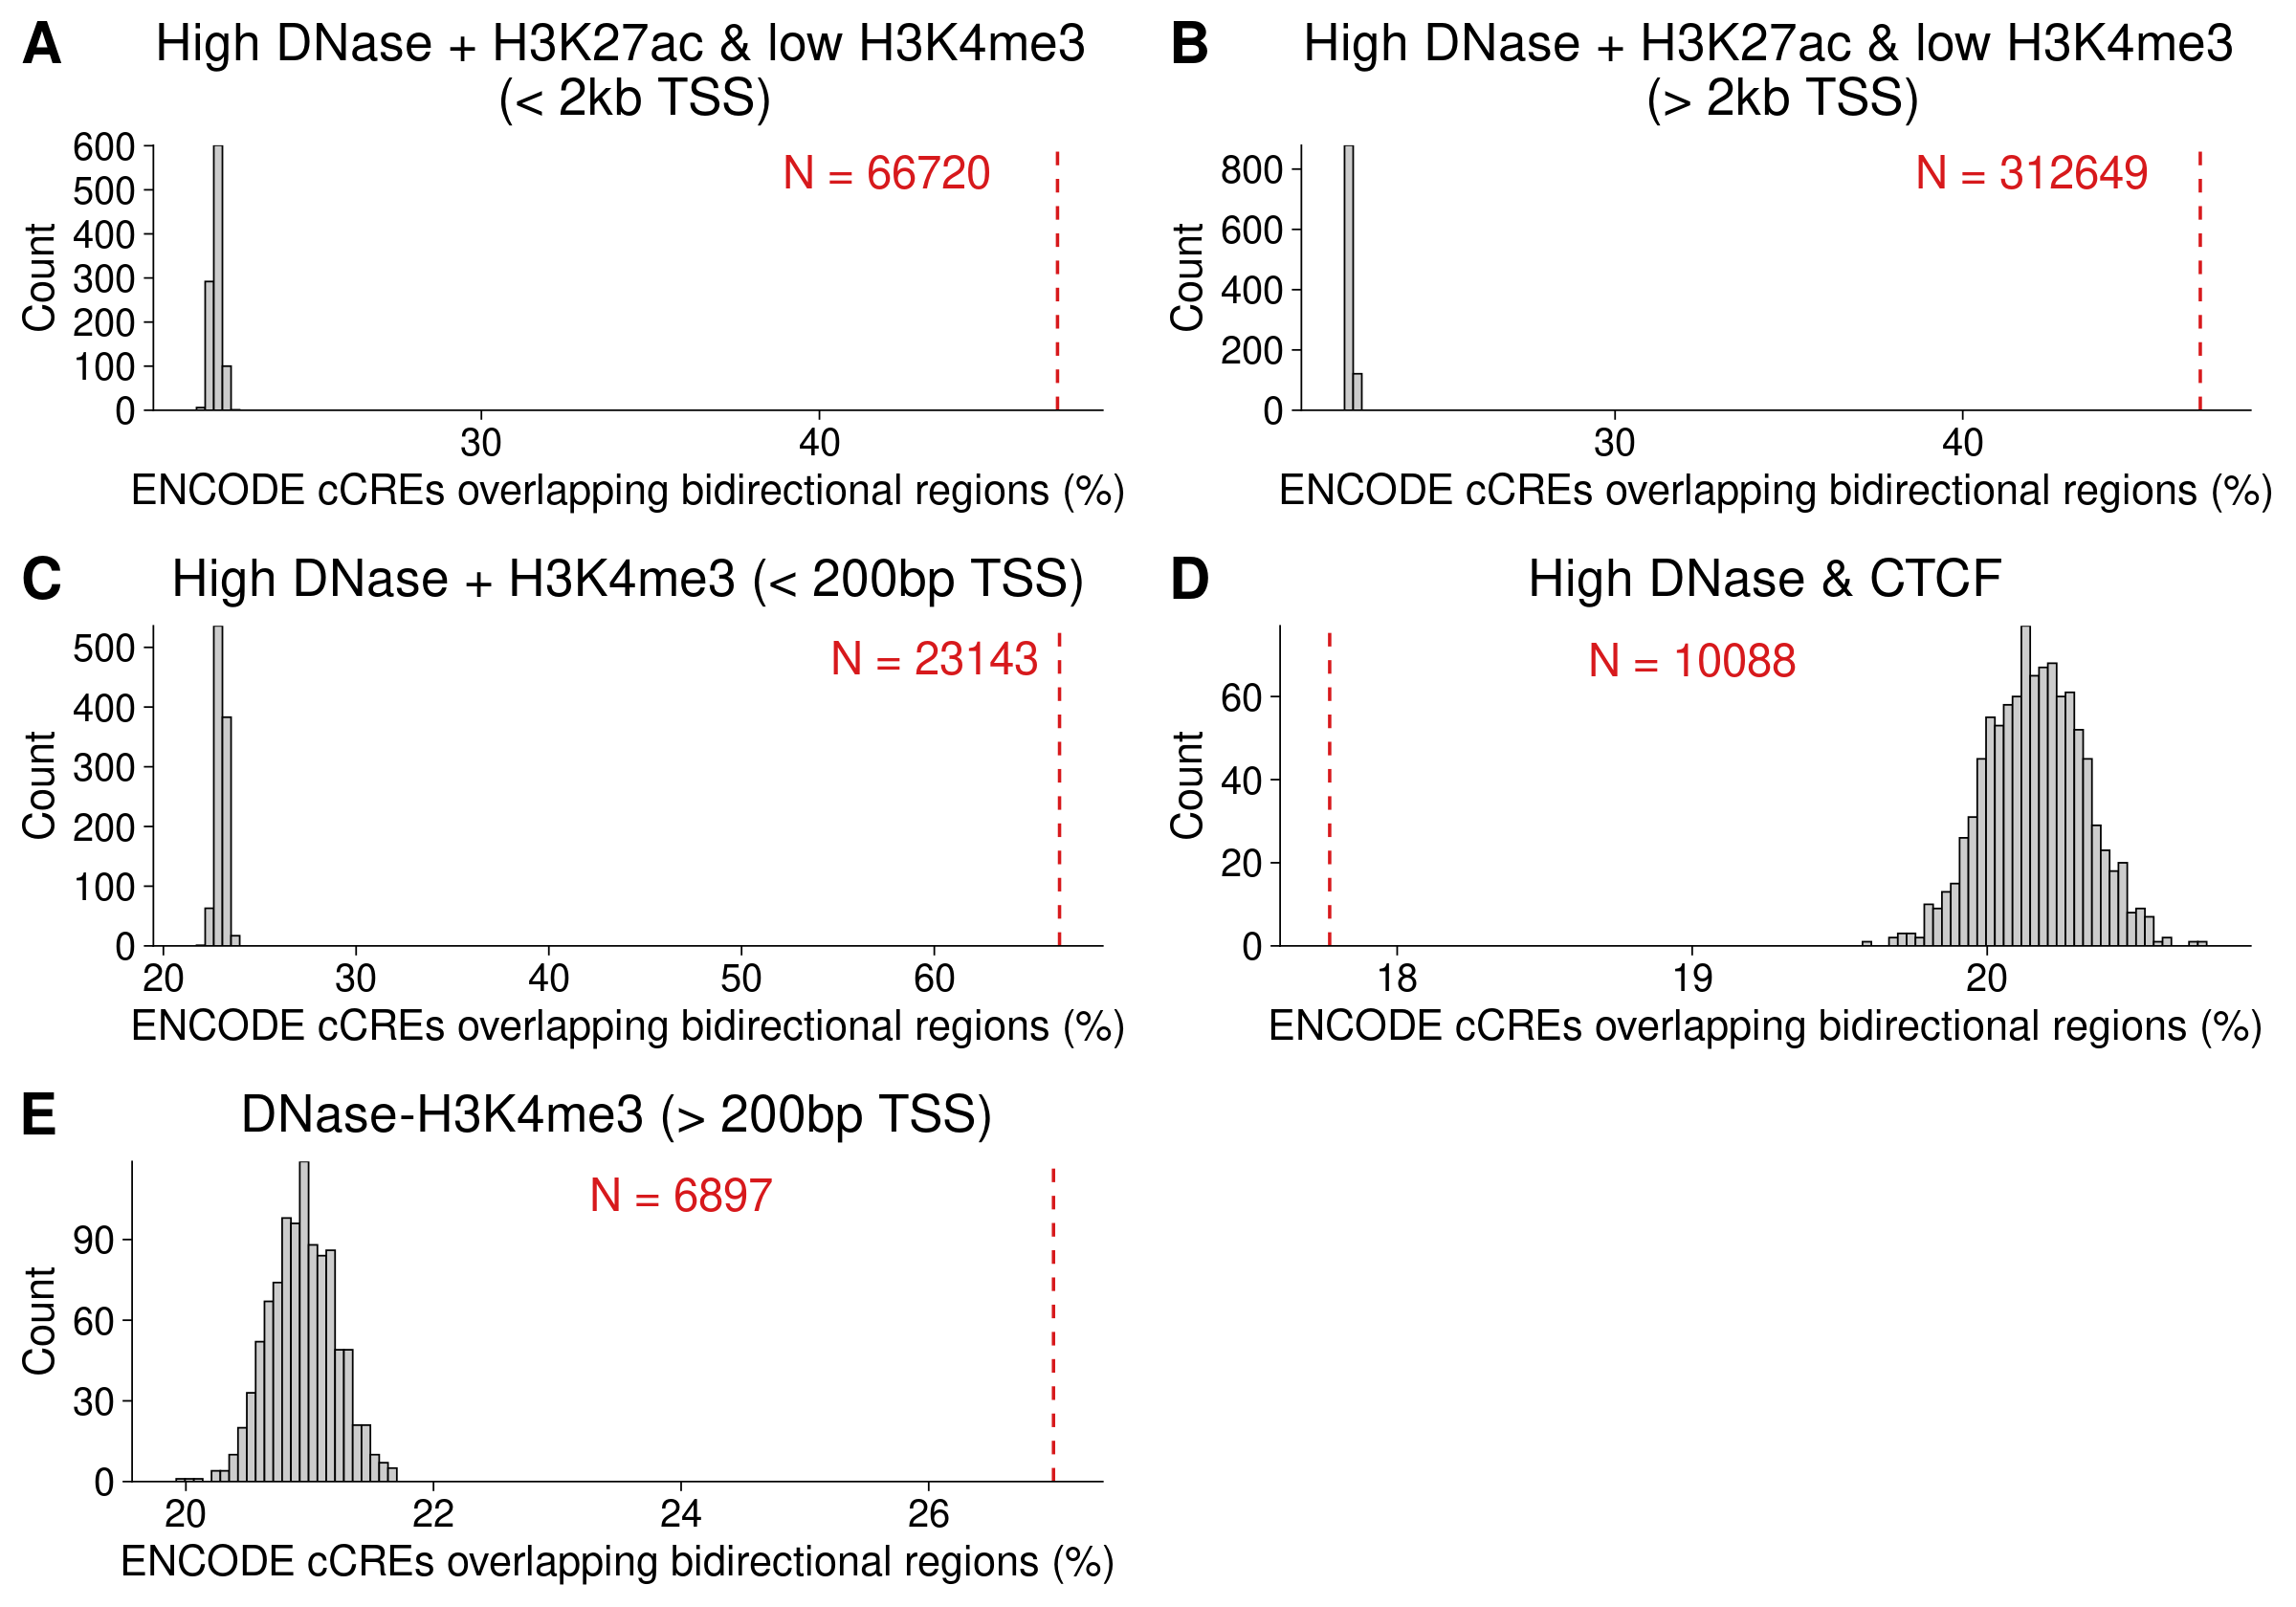

In [15]:
options(repr.plot.width=20, repr.plot.height=14)
hg38_ucsc_types_plots2 <- cowplot::plot_grid(hg38_ucsc_types_plot_list[[1]] + ggtitle("High DNase + H3K27ac & low H3K4me3 \n (< 2kb TSS)"),
                                                    hg38_ucsc_types_plot_list[[2]] + ggtitle("High DNase + H3K27ac & low H3K4me3 \n (> 2kb TSS)"),
                                                    hg38_ucsc_types_plot_list[[3]] + ggtitle("High DNase + H3K4me3 (< 200bp TSS)"),
                                                    hg38_ucsc_types_plot_list[[4]] + ggtitle("High DNase & CTCF"),
                                                    hg38_ucsc_types_plot_list[[5]] + ggtitle("DNase-H3K4me3 (> 200bp TSS)"), 
                                               nrow = 3,
                                      labels = c('A', 'B','C','D','E'),
                                      label_size = 36)
hg38_ucsc_types_plots2

In [16]:
ggsave(hg38_ucsc_types_plots2, width = 20, height = 14,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/hg38_encode_ccre_overlaps_plots.pdf", 
       bg = "transparent")

ggsave(hg38_ucsc_types_plots2, width = 20, height = 14,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/hg38_encode_ccre_overlaps_plots.png", 
       bg = "transparent")

### Mouse

In [17]:
mm10_ucsc_types <- unique(mm10_encode$ucscLabel)
mm10_ucsc_types_plot_list <- list()


for (i in mm10_ucsc_types){
    
    print("--------------------------------")
    print(i)
    
    #1: subset the encode feature
    mm10_shuffle_subtype_num <- subset(mm10_shuffle_overlap, ucscLabel == i)
    
    #2: count number of ALL encode features __by type__
    mm10_encode_subtype <- subset(mm10_encode, ucscLabel == i)
    mm10_n_encode_subtype <- length(unique(mm10_encode_subtype$encode_id))
    
    #3: get percent (%) of overlaps for all shuffled regions
    mm10_shuffle_subtype_num$perc_overlap <- 100*(mm10_shuffle_subtype_num$n_overlap/mm10_n_encode_subtype)
    
    #4: get overlapsfor TRUE SET __by type__ 
    mm10_overlap_subtype <- subset(mm10_overlap, ucscLabel == i)
    mm10_actual_overlap_encode_subtype <-length(unique(mm10_overlap_subtype$encode_id))
    mm10_actual_overlap_encode_subtype_perc <- 100*(mm10_actual_overlap_encode_subtype/mm10_n_encode_subtype)
    
    
    #5: get the p-value
    mm10_p_val_subtype <- empirical_pval(mm10_shuffle_subtype_num$perc_overlap,
                                    mm10_actual_overlap_encode_subtype_perc, 
                                    alternative = "two.sided")
    
    print(paste0(i, " P-value = ",mm10_p_val_subtype))
    print(paste0(i, " Number of recovered = ", mm10_actual_overlap_encode_subtype))
    
    #6: plot the distribution
    mm10_perc_overlap_subtype_plot <- ggplot(mm10_shuffle_subtype_num, aes(x=perc_overlap)) + 
        geom_histogram(color="black", fill="gray80", bins = 100) +
        geom_vline(xintercept = mm10_actual_overlap_encode_subtype_perc,
                   linetype="dashed", 
                        color = "#d7191c", linewidth=1) +
        scale_y_continuous(expand = c(0, 0)) +
        theme_cowplot(24) +
          labs(title = i, 
               y = "Count",
               x = "ENCODE cCREs overlapping bidirectional regions (%)") +
        theme(plot.title = element_text(hjust = 0.5, face="plain"),
              title = element_text(size = 28), 
              axis.title = element_text(size = 26), 
              axis.text = element_text(size = 24)) +
        theme(plot.margin = margin(0.5,1,0.5,0.5, "cm"))
    
     #add median counts  
     mm10_perc_overlap_subtype_plot2 <- mm10_perc_overlap_subtype_plot + annotate(geom="text", 
             x=round(0.9*max(c(mm10_shuffle_subtype_num$perc_overlap,
                               mm10_actual_overlap_encode_subtype_perc))),
             y=round(0.9*max(ggplot_build(mm10_perc_overlap_subtype_plot)$data[[1]]$count)), 
             size=10,
             label=paste0("N = ", 
                          mm10_actual_overlap_encode_subtype),
             color="#d7191c") 

    
    mm10_ucsc_types_plot_list[[i]] <- mm10_perc_overlap_subtype_plot2
    
    
}

[1] "--------------------------------"
[1] "enhD"
[1] "enhD P-value = 0.001998001998002"
[1] "enhD Number of recovered = 129882"
[1] "--------------------------------"
[1] "enhP"
[1] "enhP P-value = 0.001998001998002"
[1] "enhP Number of recovered = 40026"
[1] "--------------------------------"
[1] "prom"
[1] "prom P-value = 0.001998001998002"
[1] "prom Number of recovered = 18120"
[1] "--------------------------------"
[1] "CTCF"
[1] "CTCF P-value = 0.001998001998002"
[1] "CTCF Number of recovered = 8806"
[1] "--------------------------------"
[1] "K4m3"
[1] "K4m3 P-value = 0.001998001998002"
[1] "K4m3 Number of recovered = 5872"


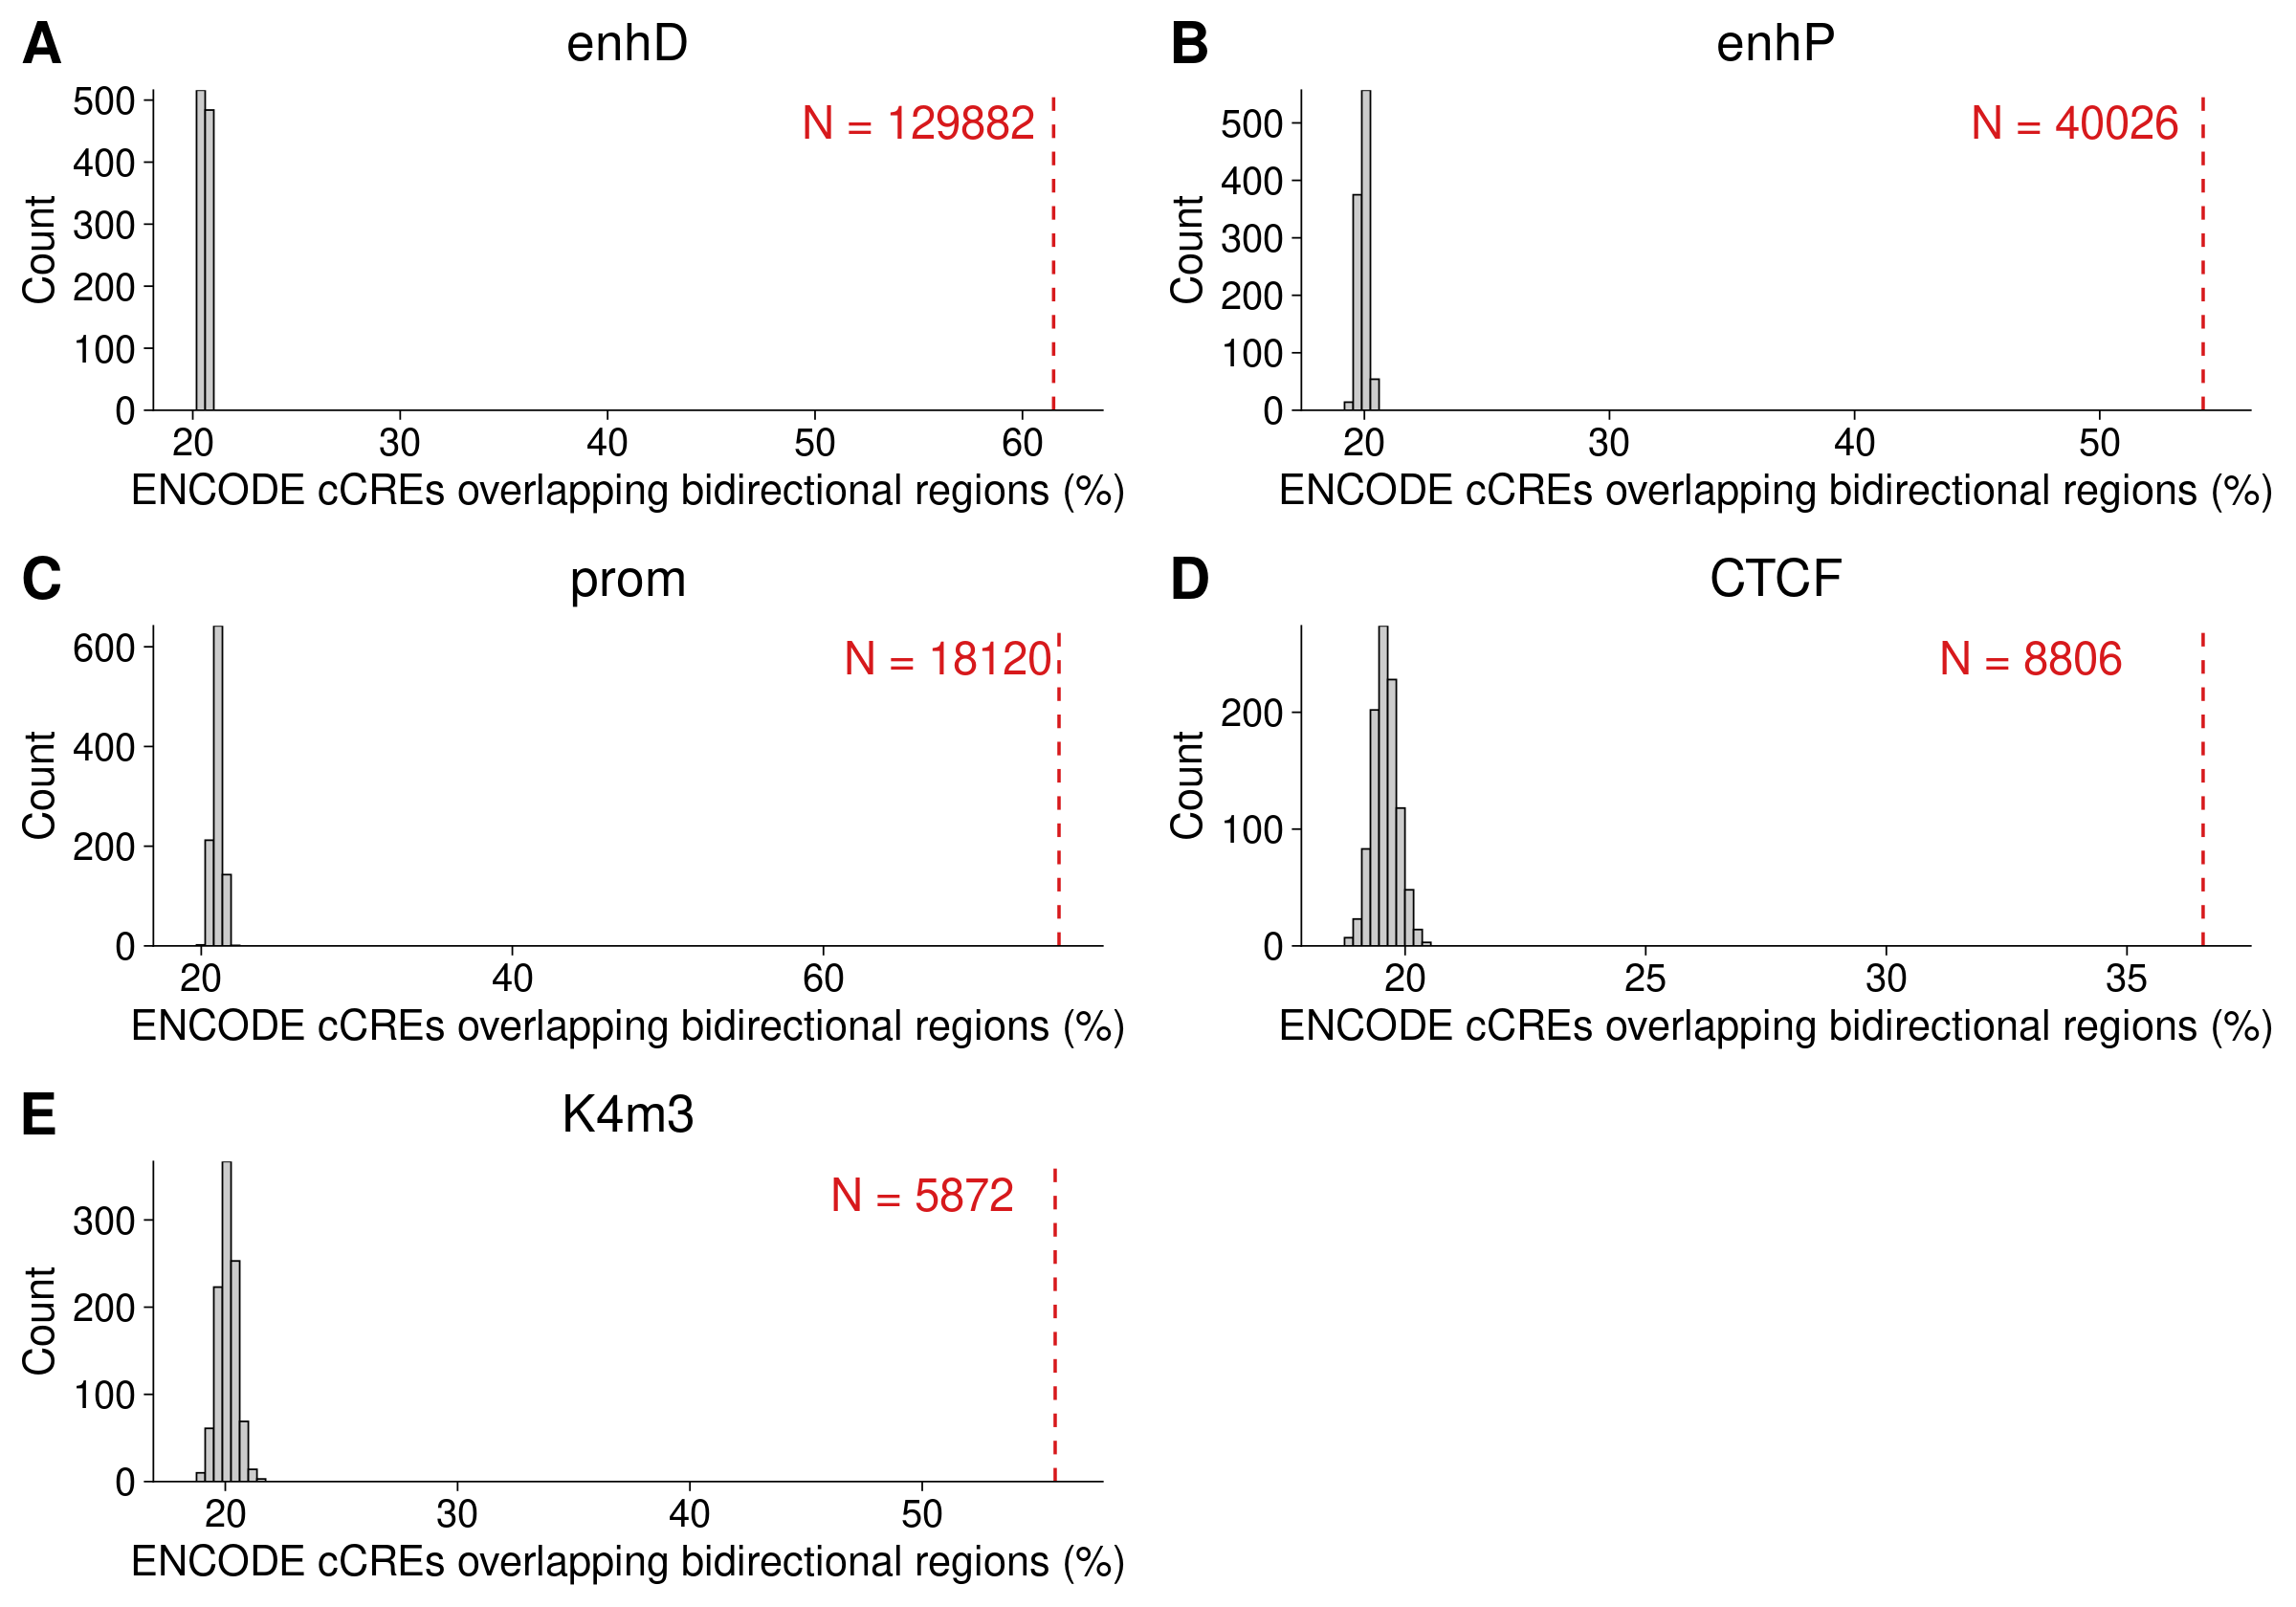

In [18]:
options(repr.plot.width=20, repr.plot.height=14)
mm10_ucsc_types_plots <- cowplot::plot_grid(plotlist = mm10_ucsc_types_plot_list, 
                                               nrow = 3,
                                      labels = c('A', 'B','C','D','E'),
                                      label_size = 36)
mm10_ucsc_types_plots

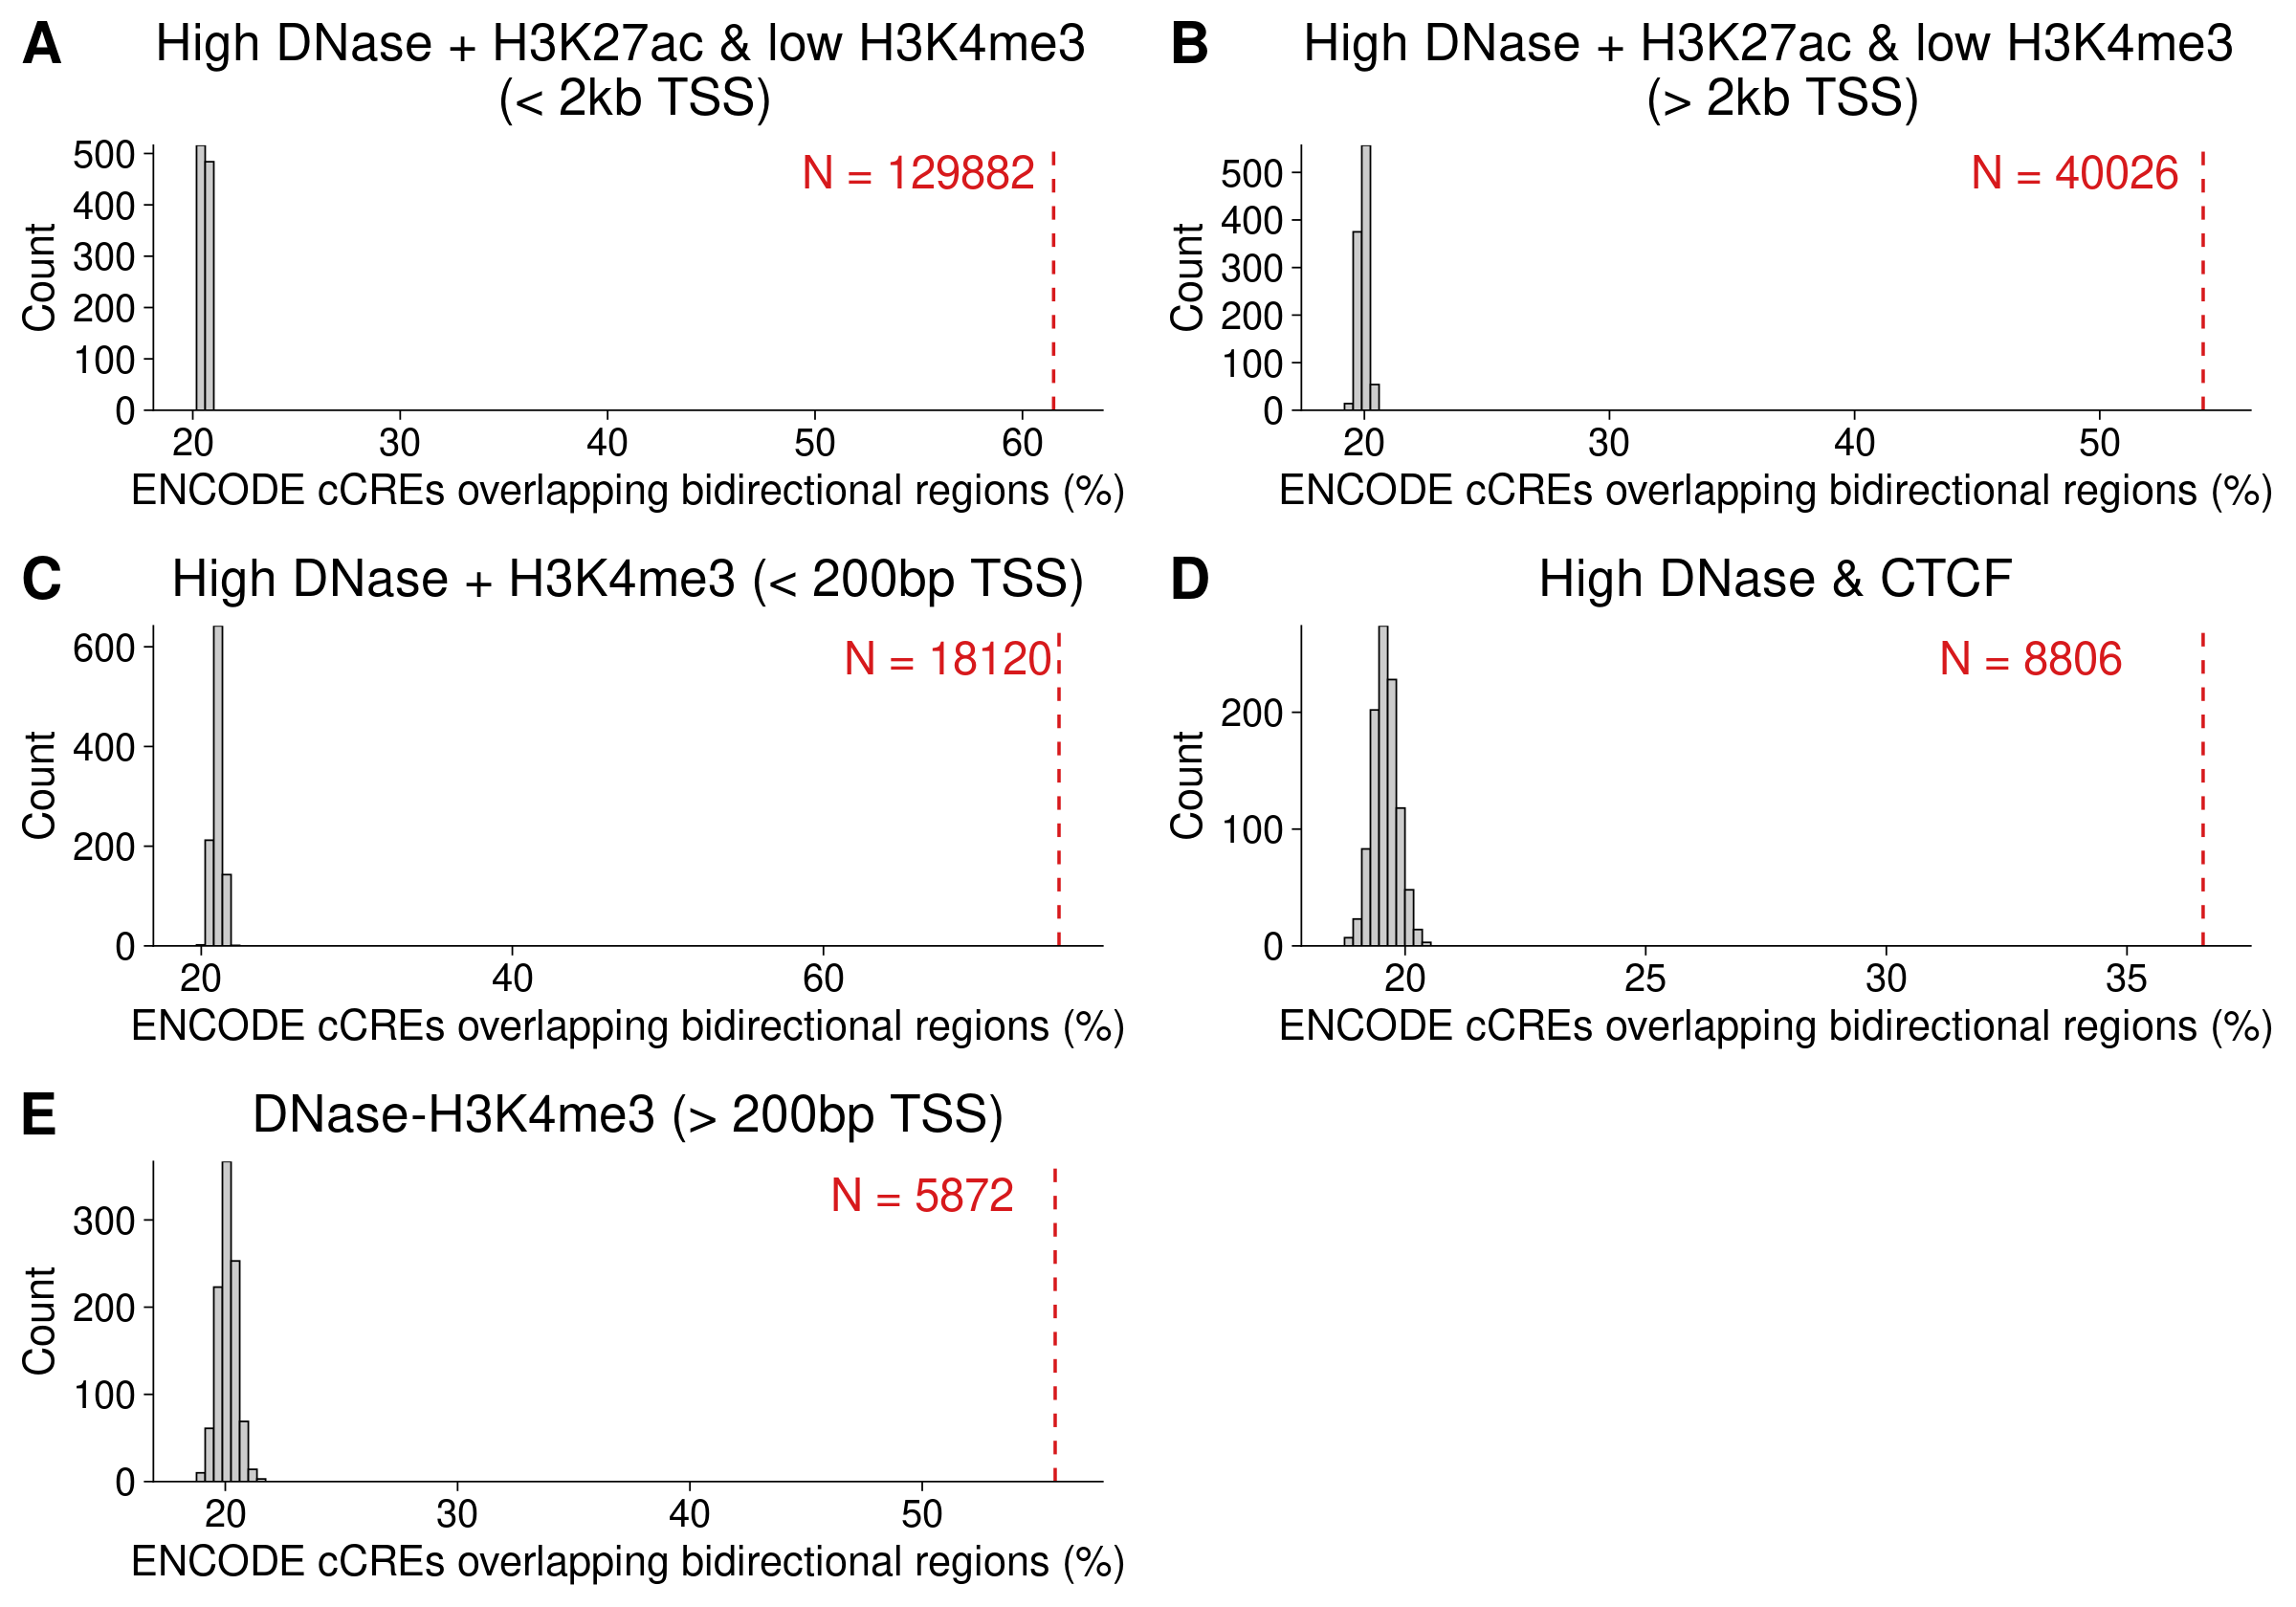

In [19]:
options(repr.plot.width=20, repr.plot.height=14)
mm10_ucsc_types_plots2 <- cowplot::plot_grid(mm10_ucsc_types_plot_list[[1]] + ggtitle("High DNase + H3K27ac & low H3K4me3 \n (< 2kb TSS)"),
                                                    mm10_ucsc_types_plot_list[[2]] + ggtitle("High DNase + H3K27ac & low H3K4me3 \n (> 2kb TSS)"),
                                                    mm10_ucsc_types_plot_list[[3]] + ggtitle("High DNase + H3K4me3 (< 200bp TSS)"),
                                                    mm10_ucsc_types_plot_list[[4]] + ggtitle("High DNase & CTCF"),
                                                    mm10_ucsc_types_plot_list[[5]] + ggtitle("DNase-H3K4me3 (> 200bp TSS)"), 
                                               nrow = 3,
                                      labels = c('A', 'B','C','D','E'),
                                      label_size = 36)
mm10_ucsc_types_plots2

In [20]:
ggsave(mm10_ucsc_types_plots2, width = 20, height = 14,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/mm10_encode_ccre_overlaps_plots.pdf", 
       bg = "transparent")

ggsave(mm10_ucsc_types_plots2, width = 20, height = 14,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/mm10_encode_ccre_overlaps_plots.png", 
       bg = "transparent")

# Summary

With the Fisher's Exact Test, most overlaps between the cCREs were significant (p-value<2.2e-16) except for the human bidirectional regions and DNase-H3K4me3 cCREs overlaps (p-value=1). While for the permutation test, most the overlaps were significant except (p-value<2.2e-16) for human bidirectional and CTCF region overlaps (p-value=1 for one-sided test). 

# Session information

In [21]:
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-pc-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /usr/lib64/libopenblasp-r0.3.3.so;  LAPACK version 3.8.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Denver
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] qvalue_2.36.0     scales_1.3.0      cowplot_1.1.3     ggplot2_3.5.1    
[5] dplyr_1.1.4       data.table_1.16.2

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_1.8.9    compiler_4.4.0    crayon_1.5.3     
 [5] tidyselect_1.2.1  Rcp